已知cold matter 密度场功率谱

$$
P_{\mathrm{CMD}}(k) = A_{s}k ^{n_{s} }T ^{2 }(k)\,,
$$

其中 $A_{s}$ 为归一化系数，通过观测数据确定。$n_{s}=0.96$ 为谱指数，$T(k)$ 是 transfer function，从给定的表格插值得到。


平滑尺度 $R$ 的密度起伏的 variance 为

$$
\sigma ^{2 }(R) = \int_{0}^{\infty } \frac{4\pi k^{2 }}{(2\pi)^{3 }} P_{\mathrm{CDM}} (k)W^{2 }(k,R)\mathrm{d}k\,,\tag{$2$}
$$

其中窗函数

$$
W(k,R) = \frac{3 \left[ \sin(kR) - (kR)\cos(kR) \right]   }{(kR)^{3 }}\,,
$$

为实空间中半径为 $R$ 的 top-hat 函数在傅里叶空间的形式。记 $\sigma(R=8h^{-1 }\mathrm{Mpc})=\sigma_{8}$ ，观测表明 $\sigma_{8}=0.82$ 。

先设 $A_{s}=1$ ，取 $R=8h^{-1 }\mathrm{Mpc},h=0.6774$ ，从Eq . (2) 中计算出 $\sigma ^{2 }(R=8h ^{-1 }\mathrm{Mpc})$ ，然后用观测值 $(0.82)^{2 }$ 除以这个结果，得到归一化系数 $A_{s}$ ，再将 $P_{\mathrm{CDM}}(k)$ 作为 $k$ 的函数画出来，$k\in (10^{-5 },10^{3 })\mathrm{Mpc}^{-1 }$ . 


In [1]:
import numpy as np
from scipy.interpolate import interp1d

data = np.loadtxt('./transfer-function.txt',skiprows=1)
data_lgk = np.log10(data[:,0])
data_lgTk = np.log10(data[:,1])

print('data_lgk:', data_lgk[0:5])
print('data_lgTk:', data_lgTk[0:5])

data_lgk: [-6.    -5.988 -5.976 -5.964 -5.952]
data_lgTk: [0. 0. 0. 0. 0.]


In [2]:
lgTk_interp = interp1d(data_lgk, data_lgTk, kind='cubic')

def Tk(k):
    lgk = np.log10(k)
    lgTk = lgTk_interp(lgk)
    return 10**lgTk

In [3]:
k = 1e2
print(f'Tk(k={k}): {Tk(k)}')

Tk(k=100.0): 6.466406067701704e-07


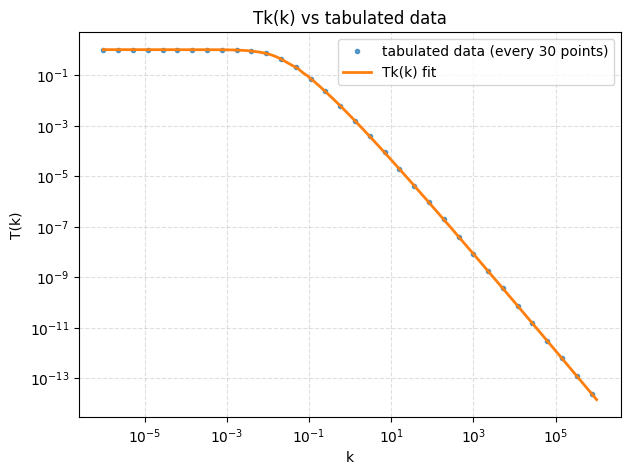

In [4]:
import matplotlib.pyplot as plt

k_values = np.logspace(np.log10(data[:, 0].min()), np.log10(data[:, 0].max()), 400)
Tk_values = Tk(k_values)

plt.figure(figsize=(7, 5))
plt.loglog(data[::30, 0], data[::30, 1], 'o', ms=3, alpha=0.7, label='tabulated data (every 30 points)')
plt.loglog(k_values, Tk_values, '-', lw=2, label='Tk(k) fit')
plt.xlabel('k')
plt.ylabel('T(k)')
plt.title('Tk(k) vs tabulated data')
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend()
plt.show()

$$
P_{\mathrm{CMD}}(k) = A_{s}k ^{n_{s} }T ^{2 }(k)\,.
$$

$$
W(k,R) = \frac{3 \left[ \sin(kR) - (kR)\cos(kR) \right]   }{(kR)^{3 }}\,.
$$

In [5]:
def P_cdm_0(k):
    A = 1.0
    n_s = 0.96
    return A * k**n_s * Tk(k)**2

def Windows(k,R):
    x = k * R
    return 3 * (np.sin(x) - x * np.cos(x)) / x**3

$$
\sigma ^{2 }(R) = \int_{0}^{\infty } \frac{4\pi k^{2 }}{(2\pi)^{3 }} P_{\mathrm{CDM}} (k)W^{2 }(k,R)\mathrm{d}k\,,\tag{$2$}\,. 
$$

In [6]:
def sigma2_R(R):
    k_min = 1e-5
    k_max = 1e5

    x = np.linspace(np.log(k_min), np.log(k_max), 2000)
    k = np.exp(x)

    integrand = k**3 * P_cdm_0(k) * Windows(k, R)**2
    sigma2 = np.trapezoid(integrand, x) / (2 * np.pi**2)

    return sigma2


In [7]:
h = 0.6774
R_0 = 8.0 / h
A_s = 0.82**2/sigma2_R(R_0)
print(f'归一化常数 As: {A_s}')

归一化常数 As: 14388594.875633167


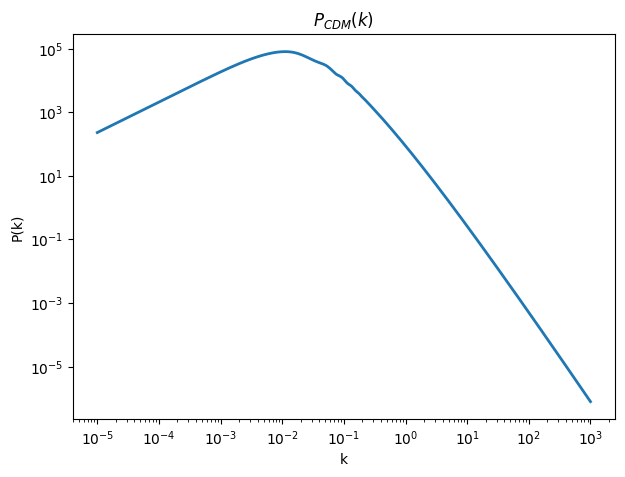

In [8]:
def P_cdm(k):
    n_s = 0.96
    return A_s * k**n_s * Tk(k)**2

k_values = np.logspace(-5, 3, 400)
P_CDM_k_values = P_cdm(k_values)

plt.figure(figsize=(7, 5))
plt.loglog(k_values, P_CDM_k_values, '-', lw=2)
plt.xlabel('k')
plt.ylabel('P(k)')
plt.title('$P_{{CDM}}(k)$')
# plt.grid(True, which='both', ls='--', alpha=0.4)
# plt.legend()
plt.show()


温暗物质的功率谱为

$$
P_{\mathrm{WDM}}(k) = P_{\mathrm{CDM}}(k)T^{2 }_{\mathrm{WDM}}(k)\,,
$$

其中

$$
T_{\mathrm{WDM}} (k) = \left( 1+ (\alpha k)^{2 \mu } \right) ^{-5/ \mu }\,,
$$

其中 $\mu=1.12$ ，以及

$$
\alpha = 0.049 \left( \frac{m_{\mathrm{WDM}}}{\mathrm{keV}} \right) ^{-1.11 } \left( \frac{\Omega_{\mathrm{WDM}}}{0.25} \right) ^{0.15 }\left( \frac{h}{0.7} \right)^{1.22 }h ^{-1 }\left[ \mathrm{Mpc} \right] \,, 
$$

取 $\Omega_{\mathrm{WDM}}=\Omega_{m}=0.32,\,m_{\mathrm{WDM}}=10\mathrm{keV} \,, m_{\mathrm{WDM}}=1 \mathrm{keV}\,, m_{\mathrm{WDM}}=0.1\mathrm{keV}$ ，将 Eq.2 的 $P_{\mathrm{CDM}}(k)$ 替换成 $P_{\mathrm{WDM}}(k)$ ，先确定 $A_{s}$ ，再画出 $P_{\mathrm{WDM}}(k)$ 

In [9]:
Omega_WDM = 0.32
def alpha_WDM(m_WDM):
    return 0.049 * (m_WDM / 1.0)**(-1.11) * (Omega_WDM / 0.25)**0.15 * (h / 0.7)**1.22 * h**(-1)

mu = 1.12
def Tk_WDM(k, m_WDM):
    alpha = alpha_WDM(m_WDM)
    return (1 + (alpha * k)**(2*mu))**(-5/mu)

def P_WDM_0(k, m_W):
    n_s = 0.96
    A_0 = 1.0
    return A_0 * k**n_s * Tk(k)**2 * Tk_WDM(k, m_W)**2

def sigma_WDM_2(R, m_W):
    k_min = 1e-5
    k_max = 1e5

    x = np.linspace(np.log(k_min), np.log(k_max), 2000)
    k = np.exp(x)

    integrand = k**3 * P_WDM_0(k, m_W) * Windows(k, R)**2
    sigma2 = np.trapezoid(integrand, x) / (2 * np.pi**2)

    return sigma2



In [10]:
sigma_WDM_2_values = [sigma_WDM_2(R_0, m_W) for m_W in [0.1, 1.0, 10.0]]
print(f'sigma_WDM_2(R_0) for m_W = 0.1, 1.0, 10.0 keV: {sigma_WDM_2_values}')

sigma_WDM_2(R_0) for m_W = 0.1, 1.0, 10.0 keV: [np.float64(4.237234724779351e-08), np.float64(4.671279944568384e-08), np.float64(4.67313952308333e-08)]


In [14]:
def As_WDM(m_W):
    return 0.82**2 / sigma_WDM_2(R_0, m_W)

m_W_values = [0.1, 1.0, 10.0]
As_WDM_values = [As_WDM(m_W) for m_W in m_W_values]
print(f'归一化常数 As_WDM for m_W = 0.1, 1.0, 10.0 keV: {As_WDM_values}')

归一化常数 As_WDM for m_W = 0.1, 1.0, 10.0 keV: [np.float64(15868840.02596798), np.float64(14394341.764548821), np.float64(14388613.836129408)]


In [15]:
def P_WDM_k(k,m_WDM):
    As = As_WDM(m_WDM)
    return As * P_WDM_0(k, m_WDM)

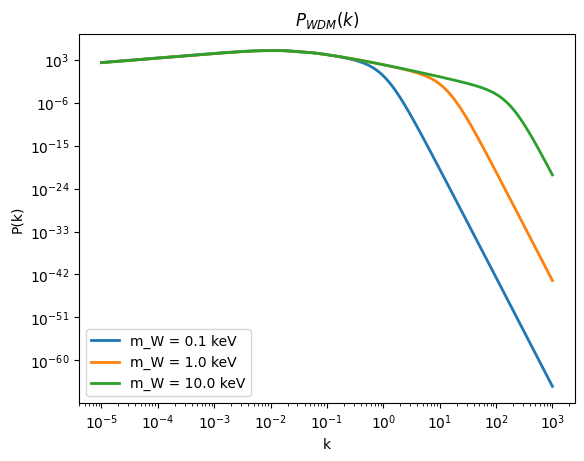

In [16]:

k_values = np.logspace(-5, 3, 400)
for m_W in m_W_values:
    P_WDM_k_values = P_WDM_k(k_values, m_W)
    plt.loglog(k_values, P_WDM_k_values, '-', lw=2)

plt.xlabel('k')
plt.ylabel('P(k)')
plt.title('$P_{{WDM}}(k)$')
# plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend(["m_W = 0.1 keV", "m_W = 1.0 keV", "m_W = 10.0 keV"])
plt.show()